<a href="https://colab.research.google.com/github/elmos-fire/pet-projects-base/blob/main/nlp_course_s01_Intro.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ODS NLP Cource: Seminar 01 - Базовые библиотеки обработки текста
Реквизиты курса:
- страница курса - [ODS NLP Cource](https://ods.ai/tracks/nlp-course-spring-2024)
- автор-ведущий курса - [Валентин Малых](http://val.maly.hk/)
- редактор-семинарист - [Салават Гарифуллин]()
- ссылка на актуальную [тетрадку](https://colab.research.google.com/drive/1GfMvQKlIyPf93YppBdGBApVuEhTz5C23)



## [1] Regular Expressions


### 1.1 Основы регулярных выражений

Регулярные выражения (Regex) – мощный инструмент для работы со строками.
```python
r'(https?://)?(www\.)?youtube\.(com|nl)/watch\?v=([\w-]+)(&.*?)?(?=[^-\w&=%])'
```

**Основные метасимволы:**

**Символьные классы:**
- `\d` — цифра `[0-9]`
- `\D` — не цифра
- `\w` — alphanumeric (буква, цифра, `_`)
- `\W` — non-alphanumeric (не буква, не цифра)
- `\s` — пробельный символ
- `\S` — не пробельный символ
- `.` — любой символ (кроме переноса строки).  
*Пример: `\d+\s\w+` — число, пробел и слово.*

**Границы (якоря):**
- `^` — начало строки
- `$` — конец строки
- `\b` — граница слова.  
*Пример: `^\b\w+` — слово в начале строки.*

**Квантификаторы (повторения):**
- `+` — 1 или более повторений
- `*` — 0 или более повторений
- `?` — 0 или 1 повторение
- `{n,m}` — от `n` до `m` повторений.  
*Пример: `\d{2,4}\w?` — от 2 до 4 цифр и необязательный буквенный символ.*

**Логика и группировка:**
- `[]` — набор символов (например `[а-я]` — кириллица)
- `()` — группировка (например, `(ab)+` — ищет `ab`, `abab` и т.д.)
- `|` — логическое ИЛИ (например `([a-z]|[0-9])+` последовательность букв или цифр)
- `[^...]` — отрицание (например `[^0-9]` — любой символ, кроме цифры)

**Песочница для тестов:** [regex101.com](https://regex101.com)

### 1.2 Токенизация с `RegEx`

In [ ]:
import re

text = 'Good muffins cost $3.88 in New York. \nPlease buy me two of them.\n\n\tThanks.'
print(text)

#### Токенизация через split

In [ ]:
# стандартный python split
tokens = text.split()
print(tokens)

In [ ]:
# сплит по пробельным символам
tokens = re.split(r'\s+', text)
print(tokens)

In [ ]:
# сплит по non-alphanumeric
tokens = re.split(r'\W+', text)
print(tokens)

#### Поиск всех подпоследовательностей по маске

`'\w+|[^\w\s]+'`:
- `\w+` : одна или более "словесных" букв (буквы, цифры, подчеркивание)
- `|` : оператор "ИЛИ"
- `[^\w\s]+` : один или более символов пунктуации (то что ни буква/цифра, ни пробел)

In [ ]:
tokens = re.findall(r'\w+|[^\w\s]+', text)
print(tokens)

`'\w+|\S+'`:
- `\w+` : слова (буквенно-цифровые последовательности)
- `\S+` : любая последовательность непробельных символов (оставшиеся случаи)

In [ ]:
tokens = re.findall(r'\w+|\S+', text)
print(tokens)

In [ ]:
# Можно извлечь чисто цены со знака доллара '$'
tokens = re.findall(r'\$[\d\.]+', text)
print(tokens)

In [ ]:
# Или только слова с заглавной буквы
tokens = re.findall(r'[A-Z]\w+', text)
print(tokens)

#### Очистка текста

In [ ]:
text_web = "<div>Привет! &nbsp; Email: admin@ods.ai. Phone: +7(999)123-45-67. Website: https://ods.ai</div>"

In [ ]:
# 1. Очистка HTML (брутальный метод)
clean_text = re.sub(r'<[^>]+>', ' ', text_web)
clean_text

In [ ]:
# 2. Очистка HTML-сущностей (например, &nbsp;, &amp;)
clean_text = re.sub(r'&[a-z]+;', ' ', clean_text)
clean_text

In [ ]:
# 3. Удаление ссылок (URL)
clean_text = re.sub(r'https?://\S+|www\.\S+', '', clean_text)
clean_text

In [ ]:
# 4. Удаление лишних пробелов и приведение к нижнему регистру
clean_text = re.sub(r'\s+', ' ', clean_text)
clean_text = clean_text.strip().lower()
clean_text

In [ ]:
import re

text_web = "<div>Привет! &nbsp; Email: admin@ods.ai. Phone: +7(999)123-45-67. Website: https://ods.ai</div>"

# 1. Очистка HTML (брутальный метод)
clean_text = re.sub(r'<[^>]+>', ' ', text_web)

# 2. Очистка HTML-сущностей (например, &nbsp;, &amp;)
clean_text = re.sub(r'&[a-z]+;', ' ', clean_text)

# 3. Удаление ссылок (URL)
clean_text = re.sub(r'https?://\S+|www\.\S+', '', clean_text)

# 4. Удаление лишних пробелов и приведение к нижнему регистру
clean_text = re.sub(r'\s+', ' ', clean_text).strip().lower()

# 5. Поиск email
# [\w\.-]+@[\w\.-]*\w : (буквы/цифры/точки/тире) + '@' + (буквы/цифры/точки/тире), заканчивается на букву/цифру
emails = re.findall(r'[\w\.-]+@[\w\.-]*[a-z]+', text_web)

# 6. Поиск телефона (сложный шаблон)
# \+?\d[\d\-\(\)\s]{7,} : опциональный '+', цифра, затем 7+ символов (цифры, тире, скобки, пробелы)
phones = re.findall(r'\+?\d[\d\-\(\)\s]{7,}', text_web)


print(f"Cleaned: {clean_text}")
print(f"Emails: {emails}")
print(f"Phones: {phones}")


### 1.3 Практика: Очистка данных

В реальных задачах текст часто "грязный" (HTML теги, смайлы, странные пробелы).

**Задача:** У нас есть тексты с веб-страниц. Нужно:
1. Удалить все HTML теги (`<...>`).
2. Заменить HTML сущности (`&nbsp;` и т.д.) на пробел.
3. Привести к нижнему регистру.
4. Удалить лишние пробелы (оставить только один).

In [ ]:
def clean_text(text: str) -> str:
    # 1. URL -> ' '
    text = re.sub(r'https?://[^\s<>"]+|www\.[^\s<>"]+', ' ', text)
    # 2. HTML Tags -> ' '
    text = re.sub(r'<[^>]+>', ' ', text)
    # 3. HTML Entities -> ' '
    text = re.sub(r'&[a-z]+;', ' ', text)
    # 4. Spaces -> ' '
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

raw = "Check <a href='https://ods.ai'>site</a>! &nbsp; Great info."
print(f'Было:\n"{raw}"\n')
print(f'Стало:\n"{clean_text(raw)}"')

### 1.4 Задачка `"Очистка данных"`
Написать очистку зашумленных данных

In [ ]:
def generate_noisy_texts(n: int = 5):
    """Генерирует тексты с HTML-тегами, спецсимволами и артефактами"""
    noisy_texts = []

    for _ in range(n):
        # Случайный русский текст
        words = [random.choice(RU_WORDS) for _ in range(random.randint(3, 7))]
        base = " ".join(words).capitalize() + "."

        # Добавляем "мусор"
        noise_patterns = [
            f"<p>{base}</p>",
            f"<div class='content'>{base} &nbsp; &copy;</div>",
            f"<!-- comment --> {base} #NLP!!!",
            f"<b>{base}</b> $100 &#8381;",
            f"<span>{base}</span> \t\t  {random.choice(EN_WORDS)}!!!"
        ]
        noisy_texts.append(random.choice(noise_patterns))

    return noisy_texts


In [ ]:
# import random

# #сгенерируем данные на основе функции выше
# noisy_samples = generate_noisy_texts(10)
# cleaner = re.compile(r'<[^>]+>|[^\w\s]|&\w+;|\s+')
# print (noisy_samples)
noisy_samples = ["<div class='content'>Разработка язык текст модель результат язык. &nbsp; &copy;</div>", '<!-- comment --> Обработка разработка разработка язык алгоритм модель. #NLP!!!', '<!-- comment --> Результат обработка обработка модель проект результат. #NLP!!!', "<div class='content'>Алгоритм модель модель. &nbsp; &copy;</div>", '<span>Алгоритм решение результат модель.</span> \t\t  ML!!!', '<b>Язык текст нейросеть текст анализ разработка.</b> $100 &#8381;', '<span>Проект текст алгоритм анализ.</span> \t\t  ML!!!', '<!-- comment --> Модель модель язык. #NLP!!!', '<!-- comment --> Текст данные обработка нейросеть алгоритм анализ. #NLP!!!', '<b>Разработка разработка алгоритм нейросеть.</b> $100 &#8381;']
cleaner = re.compile(r'<[^>]+>|[^\w\s]|&\w+;|\s+')

In [ ]:
for text in noisy_samples:
    cleaned = re.sub(r'<[^>]+>|&\w+;', '', text)          # Удаляем теги
    cleaned = re.sub(r'[^\w\s]', '', cleaned)       # Спецсимволы
    cleaned = re.sub(r'\s+', ' ', cleaned).strip()  # Лишние пробелы
    print(f"Было:  {text[:50]:<50} | Стало: {cleaned}")

Было:  <div class='content'>Разработка язык текст модель  | Стало: Разработка язык текст модель результат язык
Было:  <!-- comment --> Обработка разработка разработка я | Стало: Обработка разработка разработка язык алгоритм модель NLP
Было:  <!-- comment --> Результат обработка обработка мод | Стало: Результат обработка обработка модель проект результат NLP
Было:  <div class='content'>Алгоритм модель модель. &nbsp | Стало: Алгоритм модель модель
Было:  <span>Алгоритм решение результат модель.</span> 		 | Стало: Алгоритм решение результат модель ML
Было:  <b>Язык текст нейросеть текст анализ разработка.</ | Стало: Язык текст нейросеть текст анализ разработка 100 8381
Было:  <span>Проект текст алгоритм анализ.</span> 		  ML! | Стало: Проект текст алгоритм анализ ML
Было:  <!-- comment --> Модель модель язык. #NLP!!!       | Стало: Модель модель язык NLP
Было:  <!-- comment --> Текст данные обработка нейросеть  | Стало: Текст данные обработка нейросеть алгоритм анализ NLP
Было:  <b>Разраб

Такие "загрязнения" у текста часто появляются от некорректного парсинга или переноса из одного типа данных в другой. Например, что то аналогичное можно получить при переносе текста в dict, json, а при переносе обратно будут возникать лишние кавычки, либо непонятные теги - отправлять для очистки, такие данные в llm или специализированные библиотеки вроде NLTK, spacy - не всегда даст желаемый результат и вычислительно дороже. Например если у вас pd.DataFrame с выгруженными в непонятном формате диалогами (например html теги) - удобнее иметь униварсальный инструмент, способный очистить эти данные достаточно быстро, достаточно легко и точно.

In [ ]:
import pandas as pd

df = pd.DataFrame({'raw_text': noisy_samples})
df.head()

,raw_text
0,<div class='content'>Разработка язык текст мод...
1,<!-- comment --> Обработка разработка разработ...
2,<!-- comment --> Результат обработка обработка...
3,<div class='content'>Алгоритм модель модель. &...
4,<span>Алгоритм решение результат модель.</span...


In [ ]:
texts = df['raw_text']
texts = texts.str.replace(r'<[^>]+>|&[^;\s]+;|[^\w\s]|\s+', ' ', regex=True)
df['clean_text'] = texts

In [ ]:
df.head()

,raw_text,clean_text
0,<div class='content'>Разработка язык текст мод...,Разработка язык текст модель результат язык ...
1,<!-- comment --> Обработка разработка разработ...,Обработка разработка разработка язык алгорит...
2,<!-- comment --> Результат обработка обработка...,Результат обработка обработка модель проект ...
3,<div class='content'>Алгоритм модель модель. &...,Алгоритм модель модель
4,<span>Алгоритм решение результат модель.</span...,Алгоритм решение результат модель ML


Ниже вариант задачи для самостоятельного решения (код для генерации можно не смотреть). А вот решить задачу - убрать лишний текст из email того, кто оставил сообщение.

In [ ]:
import pandas as pd
import random
import re
import string

# Словари для генерации
RU_WORDS = ["анализ", "данные", "модель", "текст", "алгоритм", "нейросеть",
            "обработка", "язык", "разработка", "решение", "проект", "результат"]
EN_WORDS = ["AI", "NLP", "ML", "data", "model", "text", "deep", "learning"]
DOMAINS = ["gmail.com", "mail.ru", "yandex.ru", "example.com", "company.ru"]

def generate_noisy_emails(n: int = 5) -> list[str]:
    """Генерирует КРИВЫЕ email с мусором: лишние символы, обрамление, искажения"""
    noisy_emails = []

    for _ in range(n):
        # Чистый email
        clean_email = f"{random.choice(RU_WORDS)}{random.randint(1,99)}@{random.choice(DOMAINS)}"

        # Добавляем "кривизны"
        noise_patterns = [
            f"<a href='mailto:{clean_email}'>{clean_email}</a>",
            f"email: {clean_email}!!!",
            f"({clean_email})",
            f"{clean_email[:-4]}...@{clean_email.split('@')[1]}",  # частичное обрезание
            f"contact={clean_email.replace('@', ' [at] ')}",
            f"&#109;&#97;&#105;&#108;&#116;&#111;&#58;{clean_email}",  # HTML-сущности
            f"{clean_email}#comment",
            f"[{clean_email}]"
        ]
        noisy_emails.append(random.choice(noise_patterns))

    return noisy_emails

def generate_noisy_texts(n: int = 5) -> list[str]:
    """Генерирует тексты с HTML-тегами, спецсимволами и артефактами"""
    noisy_texts = []

    for _ in range(n):
        words = [random.choice(RU_WORDS) for _ in range(random.randint(3, 7))]
        base = " ".join(words).capitalize() + "."

        noise_patterns = [
            f"<p>{base}</p>",
            f"<div class='content'>{base} &nbsp; &copy;</div>",
            f"<!-- comment --> {base} #NLP!!!",
            f"<b>{base}</b> $100 &#8381;",
            f"<span>{base}</span> \t\t  {random.choice(EN_WORDS)}!!!",
            f"Телефон: +7 (972) 230-81-18 {base}",
            f"Email: user@example.com {base} &reg;"
        ]
        noisy_texts.append(random.choice(noise_patterns))

    return noisy_texts

# === 1. Создаём датафрейм с кривыми данными ===
n_samples = 10
df = pd.DataFrame({
    "noisy_email": generate_noisy_emails(n_samples),
    "noisy_text": generate_noisy_texts(n_samples)
})

df.head()

,noisy_email,noisy_text
0,[обработка71@gmail.com],Телефон: +7 (972) 230-81-18 Результат нейросет...
1,contact=разработка68 [at] gmail.com,<span>Текст алгоритм алгоритм текст язык.</spa...
2,contact=разработка95 [at] gmail.com,<p>Данные нейросеть текст анализ алгоритм.</p>
3,текст33@example...@example.com,<p>Анализ модель алгоритм проект.</p>
4,анализ21@gmail.com#comment,<b>Решение обработка текст текст.</b> $100 &#8...


In [ ]:
df['noisy_email'].apply(lambda x: re)

In [ ]:
#вариант извлечения номера
text = '+7 (972) !230-81-18'
match = re.search(r'\+7(?:\D*\d){10}', text) #паттерн находит 10 цифр после "+7"
#print (match)
result = re.sub(r'(?<=.)\D', '', match.group()) #удаляем все не числовые значения из найденного паттерна
result

Важно помнить - regular expressions жадный алгоритм и если применить алгоритм продемонстрированный выше на текст "8+7=0, а 21.12.2025 мы заказали 2 видеокарты", мы получим телефонный номер '+70211220252', что не является реальным номером телефона - мы сначала вытащим 10 цифр, расположенных после "+7", а затем уберем все символы между ними. Но при обработке зашумленных данных - алгоритм незаменим.

# [2] Text Preprocessing

## 2.1 Tokenization
Первым делом необходимо разбить текст на сущности (хотя бы на слова)

Единицы разбиения будем называть токенами, а процесс — токенизацией

### `Python`

In [ ]:
# Текст для токенизации
text = '''Good muffins cost $3.88\nin New York.  Please buy me two of them.\n\nThanks.'''
text_ru = """Хорошие кексы стоят $3,88\nв Нью-Йорке.  Пожалуйста, купите мне два таких.\n\nБлагодарю."""

In [ ]:
# Разделение на слова по пробелам
print(text.split())

In [ ]:
# Разделение на символы
print(list(text))

### NTLK

- [документация](https://www.nltk.org/)
- Natural Language Toolkit (NLTK) содежит базовые инструменты для работы с текстом
- есть выбор различных [токенизаторов](https://www.nltk.org/api/nltk.tokenize.regexp.html)
- как простые, на регулярных выражениях
- так и предобученные модели (надо подгружать)

In [ ]:
# Базовый токенизатор на регулярке \w+|[^\w\s]+
from nltk.tokenize import wordpunct_tokenize
print(wordpunct_tokenize)

In [ ]:
print(wordpunct_tokenize(text))

In [ ]:
# Можно настраивать свои токенайзеры
from nltk.tokenize import regexp_tokenize
print(regexp_tokenize(text, r'\w+|\$[\d\.]+|\S+'))
print(regexp_tokenize(text, r'\s+', gaps=True))
print(regexp_tokenize(text, r'[A-Z]\w+'))

In [ ]:
# Для более сложных реализаций нужно подгружать модели
import nltk
nltk.download(['punkt', 'punkt_tab'])

In [ ]:
# токенизация по словам
from nltk.tokenize import word_tokenize
print(word_tokenize(text))

In [ ]:
# токенизация по предложениям
from nltk.tokenize import sent_tokenize
print(sent_tokenize(text))

In [ ]:
# токенизация руссого по словам
from nltk.tokenize import word_tokenize
print(word_tokenize(text_ru, language="russian"))

### spaCy
- [документация](https://spacy.io/)
- [хабр](https://habr.com/ru/articles/531940/) человеческим языком
- токенизаторы на предобученных моделях (надо скачивать, смотреть в [каталоге](https://spacy.io/models))

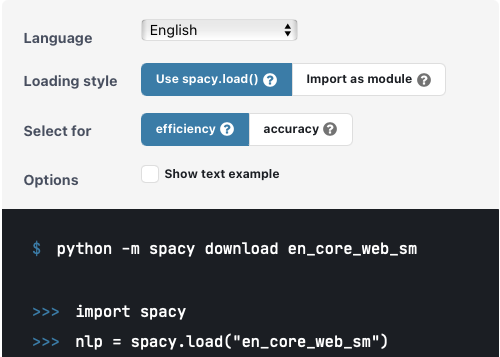

In [ ]:
# Библиотека не предустановлена, надо её установить
%pip install -qq spacy

In [ ]:
import spacy

# более быстрые и более простые модели
spacy.cli.download("en_core_web_sm")
spacy.cli.download("ru_core_news_sm")

# # более тяжёлые но более точные модели
# spacy.cli.download("en_core_web_trf")
# spacy.cli.download("ru_core_news_lg")

✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
✔ Download and installation successful
You can now load the package via spacy.load('ru_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
# объект nlp обрабатывает текст, результат -> док
nlp = spacy.load('en_core_web_sm')
doc = nlp(text)
print([token.text for token in doc])

['Good', 'muffins', 'cost', '$', '3.88', '\n', 'in', 'New', 'York', '.', ' ', 'Please', 'buy', 'me', 'two', 'of', 'them', '.', '\n\n', 'Thanks', '.']


In [ ]:
# для другого языка нужен другой nlp обработчик
nlp = spacy.load('ru_core_news_sm')
doc = nlp(text_ru)
print([token.text for token in doc])

['Хорошие', 'кексы', 'стоят', '$', '3,88', '\n', 'в', 'Нью', '-', 'Йорке', '.', ' ', 'Пожалуйста', ',', 'купите', 'мне', 'два', 'таких', '.', '\n\n', 'Благодарю', '.']


### Natasha
- [документация](https://natasha.github.io)
- [хабр](https://habr.com/ru/articles/516098/) человеческим языком
- [видео](https://www.youtube.com/watch?v=-7XT_U6hVvk&t=2034s) с демо возможностей

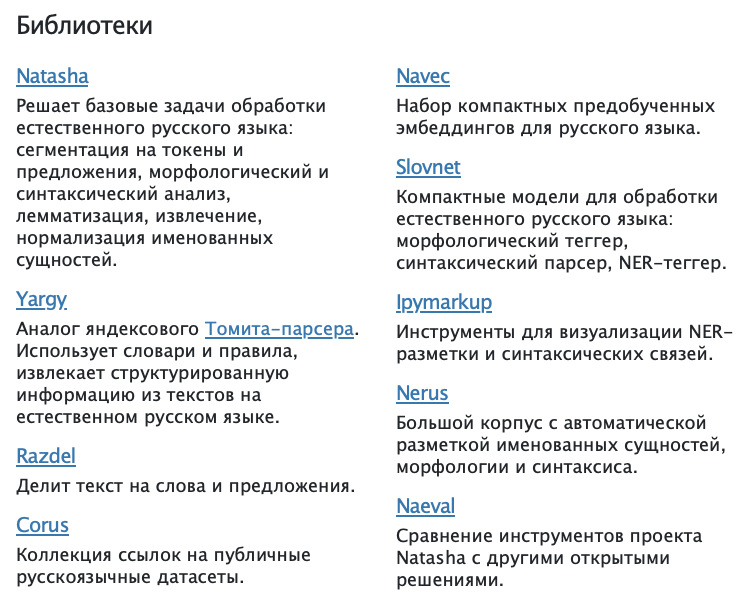

In [ ]:
%pip install -qq natasha

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.4/34.4 MB 23.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.5/55.5 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 79.6 MB/s eta 0:00:00


In [ ]:
# Тут мы сразу создаём док, в который передаём обработчики
from natasha import Doc, Segmenter

doc = Doc(text_ru)
segmenter = Segmenter()
doc.segment(segmenter)
doc

Doc(text='Хорошие кексы стоят $3,88\nв Нью-Йорке.  Пожалуйс..., tokens=[...], sents=[...])

In [ ]:
# сегментер(токенайзер) сразу делит по предложениям
doc.sents[:5]

[DocSent(stop=38, text='Хорошие кексы стоят $3,88\nв Нью-Йорке.', tokens=[...]),
 DocSent(start=40, stop=73, text='Пожалуйста, купите мне два таких.', tokens=[...]),
 DocSent(start=75, stop=85, text='Благодарю.', tokens=[...])]

In [ ]:
# и по токенам
doc.tokens[:5]

[DocToken(stop=7, text='Хорошие'),
 DocToken(start=8, stop=13, text='кексы'),
 DocToken(start=14, stop=19, text='стоят'),
 DocToken(start=20, stop=21, text='$'),
 DocToken(start=21, stop=25, text='3,88')]

In [ ]:
# аналогично для английского
doc = Doc(text)
doc.segment(segmenter)
doc.tokens[:5]

[DocToken(stop=4, text='Good'),
 DocToken(start=5, stop=12, text='muffins'),
 DocToken(start=13, stop=17, text='cost'),
 DocToken(start=18, stop=19, text='$'),
 DocToken(start=19, stop=23, text='3.88')]

### Razdel
- [документация](https://natasha.github.io/razdel)  
- часть зоопарка `Natasha`
- делает только "разделку" текстов


In [ ]:
from razdel import sentenize

print(*list(sentenize(text_ru))[:5], sep='\n')

Substring(0, 38, 'Хорошие кексы стоят $3,88\nв Нью-Йорке.')
Substring(40, 73, 'Пожалуйста, купите мне два таких.')
Substring(75, 85, 'Благодарю.')


In [ ]:
from razdel import tokenize

print(*list(tokenize(text_ru))[:5], sep='\n')

Substring(0, 7, 'Хорошие')
Substring(8, 13, 'кексы')
Substring(14, 19, 'стоят')
Substring(20, 21, '$')
Substring(21, 25, '3,88')


In [ ]:
print(*list(tokenize(text))[:5], sep='\n')

Substring(0, 4, 'Good')
Substring(5, 12, 'muffins')
Substring(13, 17, 'cost')
Substring(18, 19, '$')
Substring(19, 23, '3.88')


### Stanza
Библиотека для многоязычной обработки естественного языка от Stanford NLP Group.

In [ ]:
%pip install -q stanza

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 30.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 35.2 MB/s eta 0:00:00


In [ ]:
import stanza

# Загрузка языковой модели (например, русской)
stanza.download('ru')

INFO:stanza:Downloaded file to /root/stanza_resources/resources.json
INFO:stanza:Downloading default packages for language: ru (Russian) ...


INFO:stanza:Downloaded file to /root/stanza_resources/ru/default.zip
INFO:stanza:Finished downloading models and saved to /root/stanza_resources


In [ ]:
# Инициализация конвейера (pipeline) только с токенизатором
nlp = stanza.Pipeline('ru', processors='tokenize')

INFO:stanza:Checking for updates to resources.json in case models have been updated.  Note: this behavior can be turned off with download_method=None or download_method=DownloadMethod.REUSE_RESOURCES


INFO:stanza:Downloaded file to /root/stanza_resources/resources.json
INFO:stanza:Loading these models for language: ru (Russian):
| Processor | Package   |
-------------------------
| tokenize  | syntagrus |

INFO:stanza:Using device: cpu
INFO:stanza:Loading: tokenize
INFO:stanza:Done loading processors!


In [ ]:
# Обработка текста
doc = nlp(text_ru)

# Вывод токенов
for sentence in doc.sentences:
    for token in sentence.tokens:
        print(f"'{token.text}'", end=' ')

'Хорошие' 'кексы' 'стоят' '$' '3,88' 'в' 'Нью-Йорке' '.' 'Пожалуйста' ',' 'купите' 'мне' 'два' 'таких' '.' 'Благодарю' '.' 

In [ ]:
# Обработка текста
doc = nlp(text)

# Вывод токенов
for sentence in doc.sentences:
    for token in sentence.tokens:
        print(f"'{token.text}'", end=' ')

'Good' 'muffins' 'cost' '$' '3.88' 'in' 'New' 'York' '.' 'Please' 'buy' 'me' 'two' 'of' 'them' '.' 'Thanks' '.' 

### HuggingFace Tokenizers

In [ ]:
from tokenizers import pre_tokenizers

# Основные доступные пре-токенизаторы:
byte_level = pre_tokenizers.ByteLevel()
punctuation = pre_tokenizers.Punctuation()
metaspace = pre_tokenizers.Metaspace()
digits = pre_tokenizers.Digits(individual_digits=True)
whitespace_split = pre_tokenizers.WhitespaceSplit()
bert = pre_tokenizers.BertPreTokenizer()

# Можно комбинировать несколько пре-токенизаторов
sequence = pre_tokenizers.Sequence([
    pre_tokenizers.Whitespace(),
    pre_tokenizers.Punctuation()
])

print(bert.pre_tokenize_str(text))

[('Good', (0, 4)), ('muffins', (5, 12)), ('cost', (13, 17)), ('$', (18, 19)), ('3', (19, 20)), ('.', (20, 21)), ('88', (21, 23)), ('in', (24, 26)), ('New', (27, 30)), ('York', (31, 35)), ('.', (35, 36)), ('Please', (38, 44)), ('buy', (45, 48)), ('me', (49, 51)), ('two', (52, 55)), ('of', (56, 58)), ('them', (59, 63)), ('.', (63, 64)), ('Thanks', (66, 72)), ('.', (72, 73))]


## 2.2. Stemming
- далее необходимо разобраться с разнообразием форм
- это можно сделать путём усечения слова до основы
- как правило такие модели основаны на регулярных выражениях

### NTLK
- есть выбор [различных стеммеров](https://www.nltk.org/howto/stem.html)
- возьмём `Snowball`, он реализован для многих языков
```python
>>> print(" ".join(SnowballStemmer.languages))
arabic danish dutch english finnish french german hungarian italian
norwegian porter portuguese romanian russian spanish swedish
```

In [ ]:
from nltk.stem import SnowballStemmer
from nltk.tokenize import word_tokenize

stemmer = SnowballStemmer("english")
tokens = word_tokenize(text)
print(*tokens)
print(*[stemmer.stem(word) for word in tokens])

Good muffins cost $ 3.88 in New York . Please buy me two of them . Thanks .
good muffin cost $ 3.88 in new york . pleas buy me two of them . thank .


In [ ]:
stemmer = SnowballStemmer("russian")
tokens = word_tokenize(text_ru)
print(*tokens)
print(*[stemmer.stem(word) for word in tokens])

Хорошие кексы стоят $ 3,88 в Нью-Йорке . Пожалуйста , купите мне два таких . Благодарю .
хорош кекс сто $ 3,88 в нью-йорк . пожалуйст , куп мне два так . благодар .


## 2.3 Lemmatization & Morphology
- альтернативный вариант усечению слов до основы — восстановление основы слова
- мы не проходили задачу определения морфологии (предсказание тегов)
- но по сути именно морфология лежит под капотом многих лемматизаторов


### NLTK
- включён только словарный лемматайзер на базе словаря WordNet
- лемматизирует только если слово есть в словаре, зато быстро
- не работает с контекстом или регулярными выражениями
- сам словарь WordNet англоязычный, но есть [Open Multilingual Wordnet](https://omwn.org/news.html)
- явной лемматизации для других языков нет, но есть [теггинг](https://www.nltk.org/book/ch05.html)

In [ ]:
import nltk
nltk.download(['wordnet'])

[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [ ]:
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

wnl = WordNetLemmatizer()
print(*word_tokenize(text))
print(*map(wnl.lemmatize, word_tokenize(text)))

Good muffins cost $ 3.88 in New York . Please buy me two of them . Thanks .
Good muffin cost $ 3.88 in New York . Please buy me two of them . Thanks .


In [ ]:
# Open Multilingual Wordnet
import nltk
nltk.download(['omw-1.4', 'extended_omw'])

[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data] Downloading package extended_omw to /root/nltk_data...


True

In [ ]:
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet as wn
wnl = WordNetLemmatizer()
wn.add_exomw()

def nltk_lemmatize(word):
    lemma = min((wnl.lemmatize(word.lower(), pos) for pos in 'nvars'),  key=lambda x: len(x) - (x!=word))
    morph = min((m if (m:=wn.morphy(lemma, pos)) else lemma for pos in 'nvars'), key=lambda x: len(x) - (x!=lemma))
    return morph

print(*map(nltk_lemmatize, word_tokenize(text)))

good muffin cost $ 3.88 in new york . please buy me two of them . thank .


### spaCy
- подходит как универсальное решение и для английского, и для русского
- для каждого языка нуждна своя модель
- снимает омонимии в русском, но ошибается в более простых ситуациях

In [ ]:
import spacy

nlp = spacy.load('en_core_web_sm')
doc = nlp(text)
print(*[token.text for token in doc if token.pos_ != 'SPACE'])
print(*[token.lemma_ for token in doc if token.pos_ != 'SPACE'])

Good muffins cost $ 3.88 in New York . Please buy me two of them . Thanks .
good muffin cost $ 3.88 in New York . please buy I two of they . thank .


In [ ]:
nlp = spacy.load('ru_core_news_sm')
doc = nlp(text_ru)
print(*[token.text for token in doc if token.pos_ != 'SPACE'])
print(*[token.lemma_ for token in doc if token.pos_ != 'SPACE'])

Хорошие кексы стоят $ 3,88 в Нью - Йорке . Пожалуйста , купите мне два таких . Благодарю .
хороший кекс стоять $ 3,88 в нью - йорк . пожалуйста , купить мне два такой . благодарить .


In [ ]:
# Разрешение омонимии
def spacy_lemmatize(text, nlp=spacy.load('ru_core_news_sm')):
    return [token.lemma_ for token in nlp(text)]

print(*spacy_lemmatize('Я вылечу'))
print(*spacy_lemmatize('Я вылечу на самолете'))
print(*spacy_lemmatize('Я вылечу больного'))
print(*spacy_lemmatize('Я вылечу на самолете больного'))
print(*spacy_lemmatize('Один гвоздик или много гвоздик'))
print(*spacy_lemmatize('Прибежала жучка принесла жучка'))

я вылечить
я вылечить на самолёт
я вылечить больного
я вылечить на самолёт больной
один гвоздик или много гвоздика
прибежать жучка принести жучка


### PyMorphy2
- [документация](https://pymorphy2.readthedocs.io/en/stable/user/guide.html)
- по умолчанию работает как анализатор морфологии для русского языка,
- есть "словари" для других морфологических языком
- можно создать и под свой
- НО работает **только по 1 слову**, т.е. не снимает омонимию по контексту

In [ ]:
%pip install -q pymorphy3

In [ ]:
import pymorphy3

morph = pymorphy3.MorphAnalyzer()
print(*morph.parse('стали'), sep='\n')

Parse(word='стали', tag=OpencorporaTag('VERB,perf,intr plur,past,indc'), normal_form='стать', score=0.975342, methods_stack=((DictionaryAnalyzer(), 'стали', 945, 4),))
Parse(word='стали', tag=OpencorporaTag('NOUN,inan,femn sing,gent'), normal_form='сталь', score=0.010958, methods_stack=((DictionaryAnalyzer(), 'стали', 13, 1),))
Parse(word='стали', tag=OpencorporaTag('NOUN,inan,femn plur,nomn'), normal_form='сталь', score=0.005479, methods_stack=((DictionaryAnalyzer(), 'стали', 13, 6),))
Parse(word='стали', tag=OpencorporaTag('NOUN,inan,femn sing,datv'), normal_form='сталь', score=0.002739, methods_stack=((DictionaryAnalyzer(), 'стали', 13, 2),))
Parse(word='стали', tag=OpencorporaTag('NOUN,inan,femn sing,loct'), normal_form='сталь', score=0.002739, methods_stack=((DictionaryAnalyzer(), 'стали', 13, 5),))
Parse(word='стали', tag=OpencorporaTag('NOUN,inan,femn plur,accs'), normal_form='сталь', score=0.002739, methods_stack=((DictionaryAnalyzer(), 'стали', 13, 9),))


In [ ]:
# Склонение слов
m = morph.parse('кот')[0]
m.inflect({'gent'}).word

'кота'

In [ ]:
# Лемматизация не заработает без сторонней токенизации
tokens = word_tokenize(text_ru)
print(*tokens)
print(*[morph.parse(token)[0].normal_form for token in tokens])

Хорошие кексы стоят $ 3,88 в Нью-Йорке . Пожалуйста , купите мне два таких . Благодарю .
хороший кекс стоять $ 3,88 в нью-йорк . пожалуйста , купить я два такой . благодарить .


In [ ]:
# Разрешение омонимии (без контекста)
def morph_lemmatize(text, tokenize=word_tokenize):
    return [morph.parse(token)[0].normal_form for token in tokenize(text)]

print(*morph_lemmatize('Я вылечу'))
print(*morph_lemmatize('Я вылечу на самолёте'))
print(*morph_lemmatize('Я вылечу больного'))
print(*morph_lemmatize('Я вылечу на самолёте больного'))
print(*morph_lemmatize('Один гвоздик или много гвоздик'))
print(*morph_lemmatize('Прибежала жучка принесла жучка'))

я вылечить
я вылечить на самолёт
я вылечить больной
я вылечить на самолёт больной
один гвоздика или много гвоздика
прибежать жучок принести жучок


### Natasha
- для лемматизации решает проблему `PyMorphy3` подставлением тегов
- сперва анализирует текст целиком и предсказывавет теги
- а вердикт ставит `PyMorphy3` по каждому слово+тег в отдельности
- как итог справляется чуть лучше

In [ ]:
from natasha import Doc, MorphVocab, Segmenter, NewsEmbedding, NewsMorphTagger

segmenter = Segmenter()                    # токенайзер/сегментер
morph_vocab = MorphVocab()                 # морфологический словарь от PyMorphy
emb = NewsEmbedding()                      # векторайзер обученный на новостях
morph_tagger = NewsMorphTagger(emb)        # анализатор обученный на новостях

def natasha_lemmatize(text):
    doc = Doc(text)                        # создаём док
    doc.segment(segmenter)                 # режем на токены
    doc.tag_morph(morph_tagger)            # предсказываем морфологические теги
    for token in doc.tokens:               # проходимся словарём по каждому токен+тег
        token.lemmatize(morph_vocab)
    return [token.lemma for token in doc.tokens]

print(*word_tokenize(text_ru))
print(*natasha_lemmatize(text_ru))

Хорошие кексы стоят $ 3,88 в Нью-Йорке . Пожалуйста , купите мне два таких . Благодарю .
хороший кекс стоять $ 3,88 в нью-йорк . пожалуйста , купить я два такой . благодарить .


In [ ]:
# Разрешение омонимии
print(*natasha_lemmatize('Я вылечу'))
print(*natasha_lemmatize('Я вылечу на самолёте'))
print(*natasha_lemmatize('Я вылечу больного'))
print(*natasha_lemmatize('Я вылечу на самолёте больного'))
print(*natasha_lemmatize('Один гвоздик или много гвоздик'))
print(*natasha_lemmatize('Прибежала жучка принесла жучка'))

я вылечить
я вылечить на самолет
я вылечить больной
я вылечить на самолет больной
один гвоздика или много гвоздика
прибежать жучка принести жучок


### MyStem
- [документация](https://yandex.ru/dev/mystem)
- гораздо лучше решает проблему снятия омонимии из контекста
- но как можете заметить, ни одно решение не ультимативно

In [ ]:
%pip install -q pymystem3

In [ ]:
# Анализ с тегами
from pymystem3 import Mystem

m = Mystem()
print(m.lemmatize(text_ru))

Installing mystem to /root/.local/bin/mystem from http://download.cdn.yandex.net/mystem/mystem-3.1-linux-64bit.tar.gz


['хороший', ' ', 'кекс', ' ', 'стоять', ' ', '$', '3', ',', '88', '\n', 'в', ' ', 'нью-йорк', '.  ', 'пожалуйста', ', ', 'купить', ' ', 'я', ' ', 'два', ' ', 'такой', '.', '\n', '\n', 'благодарить', '.', '\n']


In [ ]:
# отфильтруем пробелы и лемматизатор готов
def mystem_lemmatize(text):
    return list(filter(lambda x: len(x.strip()), m.lemmatize(text)))

print(*word_tokenize(text_ru))
print(*mystem_lemmatize(text_ru))

Хорошие кексы стоят $ 3,88 в Нью-Йорке . Пожалуйста , купите мне два таких . Благодарю .
хороший кекс стоять $ 3 , 88 в нью-йорк .   пожалуйста ,  купить я два такой . благодарить .


In [ ]:
# Разрешение омонимии
print(*mystem_lemmatize('Я вылечу'))
print(*mystem_lemmatize('Я вылечу на самолёте'))
print(*mystem_lemmatize('Я вылечу больного'))
print(*mystem_lemmatize('Я вылечу на самолёте больного'))
print(*mystem_lemmatize('Один гвоздик или много гвоздик'))
print(*mystem_lemmatize('Прибежала жучка принесла жучка'))

я вылечивать
я вылетать на самолет
я вылечивать больной
я вылетать на самолет больной
один гвоздик или много гвоздик
прибегать жучка приносить жучка


### Stanza

In [ ]:
import stanza

nlp = stanza.Pipeline('ru', processors='tokenize,pos,lemma', verbose=False)

def mystem_stanza(text):
    doc = nlp(text)
    return [f"{word.lemma}" for sent in doc.sentences for word in sent.words]

In [ ]:
# Разрешение омонимии
print(*mystem_stanza('Я вылечу'))
print(*mystem_stanza('Я вылечу на самолёте'))
print(*mystem_stanza('Я вылечу больного'))
print(*mystem_stanza('Я вылечу на самолёте больного'))
print(*mystem_stanza('Один гвоздик или много гвоздик'))
print(*mystem_stanza('Прибежала жучка принесла жучка'))

я вылеть
я вылеть на самолет
я вылеть больной
я вылеть на самолет больной
один гвоздик или много гвоздик
прибегнуть жучка принести жучка


## 2.4 Stop words
- много неинформативных слов может мешает составить представление о тексте
- такие мешающиеся слова называются стоп-словами
- при необходимости их можно отфильтровывать из наших текстов

### NLTK

In [ ]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

tokens = word_tokenize(text)
stop_words = stopwords.words('english')
print(*tokens)
print(*[word for word in tokens if word not in stop_words])

Good muffins cost $ 3.88 in New York . Please buy me two of them . Thanks .
Good muffins cost $ 3.88 New York . Please buy two . Thanks .


In [ ]:
tokens = word_tokenize(text_ru)
stop_words = stopwords.words('russian')
print(*tokens)
print(*[word for word in tokens if word not in stop_words])

Хорошие кексы стоят $ 3,88 в Нью-Йорке . Пожалуйста , купите мне два таких . Благодарю .
Хорошие кексы стоят $ 3,88 Нью-Йорке . Пожалуйста , купите таких . Благодарю .


### spaCy

In [ ]:
import spacy

nlp = spacy.load('en_core_web_sm')
doc = nlp(text)
stop_words = nlp.Defaults.stop_words

tokens = [token.text for token in doc if token.pos_ != 'SPACE']
print(*tokens)
print(*[token for token in tokens if token not in stop_words])

Good muffins cost $ 3.88 in New York . Please buy me two of them . Thanks .
Good muffins cost $ 3.88 New York . Please buy . Thanks .


In [ ]:
nlp = spacy.load('ru_core_news_sm')
doc = nlp(text_ru)
stop_words = nlp.Defaults.stop_words

tokens = [token.text for token in doc if token.pos_ != 'SPACE']
print(*tokens)
print(*[token for token in tokens if token not in stop_words])

Хорошие кексы стоят $ 3,88 в Нью - Йорке . Пожалуйста , купите мне два таких . Благодарю .
Хорошие кексы стоят $ 3,88 Нью - Йорке . Пожалуйста , купите два . Благодарю .


## 2.5 Syntactic parsing
- синтаксический разбор, как и морфология, строится на предсказании тегов,
- так что демонстрация просто в ознакомительных целях



### spaCy


In [ ]:
# рендер синтаксиса из построенного дока
import spacy

nlp = spacy.load('ru_core_news_sm')
doc = nlp(text_ru)
spacy.displacy.render(doc, style="dep", jupyter=True)

### Natasha

In [ ]:
from natasha import Segmenter, NewsEmbedding, NewsSyntaxParser, Doc

segmenter = Segmenter()                    # токенайзер/сегментер
morph_vocab = MorphVocab()                 # морфологический словарь от pymorphy
emb = NewsEmbedding()                      # векторайзер обученный на новостях
syntax_parser = NewsSyntaxParser(emb)      # анализатор обученный на новостях

doc = Doc(text_ru)                         # создаём док
doc.segment(segmenter)                     # режем на токены
doc.parse_syntax(syntax_parser)            # делаем синтаксический разбор

doc.sents[0].syntax.print()                # выводим синтаксический анализ

      ┌► Хорошие   amod
    ┌►└─ кексы     nsubj
┌───└─┌─ стоят     
│ ┌─┌─└► $         obj
│ │ └──► 3,88      nummod
│ │   ┌► в         case
│ └──►└─ Нью-Йорке nmod
└──────► .         punct


# [3] Первичный анализ текстов

## 3.1 Загрузка данных

In [ ]:
!wget -q https://github.com/mhjabreel/CharCnn_Keras/raw/master/data/ag_news_csv/train.csv -O news.csv

In [ ]:
import pandas as pd

df = pd.read_csv('news.csv', names=['class', 'title', 'text'])
df

,class,title,text
0,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli..."
1,3,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...
2,3,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...
3,3,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...
4,3,"Oil prices soar to all-time record, posing new...","AFP - Tearaway world oil prices, toppling reco..."
...,...,...,...
119995,1,Pakistan's Musharraf Says Won't Quit as Army C...,KARACHI (Reuters) - Pakistani President Perve...
119996,2,Renteria signing a top-shelf deal,Red Sox general manager Theo Epstein acknowled...
119997,2,Saban not going to Dolphins yet,The Miami Dolphins will put their courtship of...
119998,2,Today's NFL games,PITTSBURGH at NY GIANTS Time: 1:30 p.m. Line: ...


In [ ]:
news = df.groupby('class')['text'].apply('\n\n'.join)
news

,text
class,
1,Reuters - Venezuelans turned out early\and in ...
2,AP - Michael Phelps took care of qualifying fo...
3,"Reuters - Short-sellers, Wall Street's dwindli..."
4,Reuters - Was absenteeism a little high\on Tue...


## 3.2 Подсчёт статистики встречаемости слов в тексте

In [ ]:
import nltk
nltk.download('punkt')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [ ]:
from nltk.probability import FreqDist
from nltk.tokenize import word_tokenize

# лемматизируем токены
tokens = word_tokenize(news[1])

# возьмём частоты по леммам и выведем топ-5 слов
fdist = FreqDist(tokens)
fdist.most_common(5)

[('the', 41858), (',', 35011), ('.', 30045), ('a', 26242), ('of', 25815)]

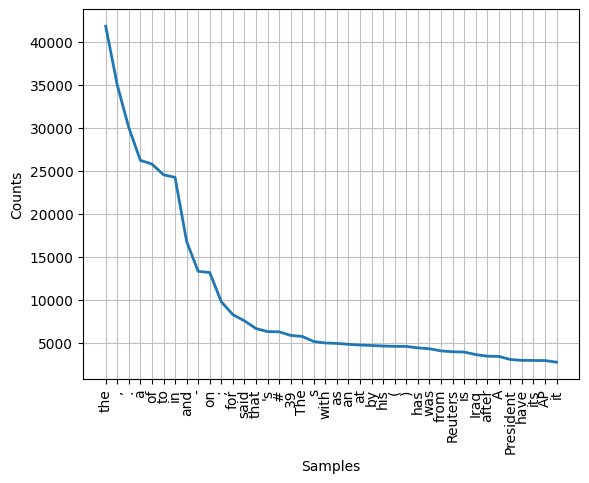

In [ ]:
# по закону Ципфа, самые часты слова — самые бессмысленные
fdist.plot(40, cumulative=False);

## 3.3 Визуализация в виде облака слов
- [документация](https://amueller.github.io/word_cloud/)
- [медиум](https://medium.com/@m3redithw/wordclouds-with-python-c287887acc8b) с красивыми примерами

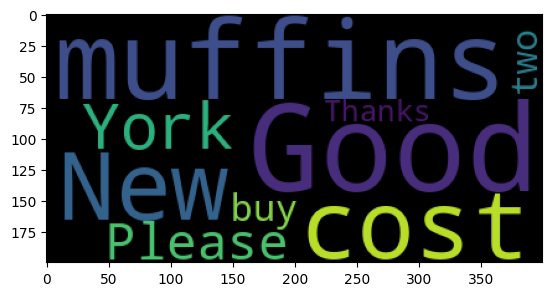

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
%matplotlib inline

wc = WordCloud().generate(text)
plt.imshow(wc)

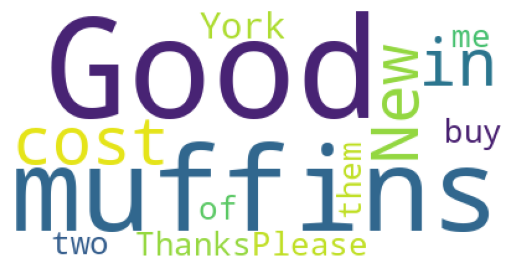

In [ ]:
# Сделаем оформление облака чуть удобнее и красивее
def word_cloud_plot(text, stopwords=[]):
    wc = WordCloud(                # создадим ворднет
        background_color='white',  # зададим белый фон
        max_words=2000,            # ограничим топ слов
        stopwords=stopwords)       # и стоп-слова
    wc.generate(text)              # передадим текст
    plt.imshow(wc)                 # создадим рисунок
    plt.axis('off')                # уберём оси
    return plt.show()              # готово

word_cloud_plot(text)

### Визуализация топа целиком

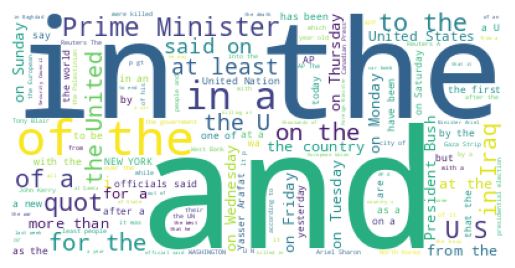

In [ ]:
word_cloud_plot(news[1])

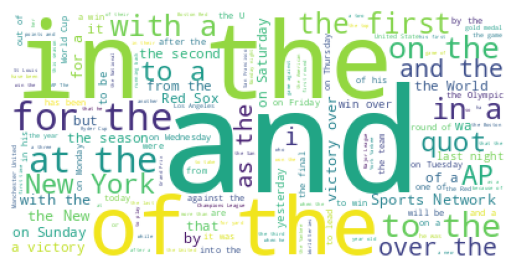

In [ ]:
word_cloud_plot(news[2])

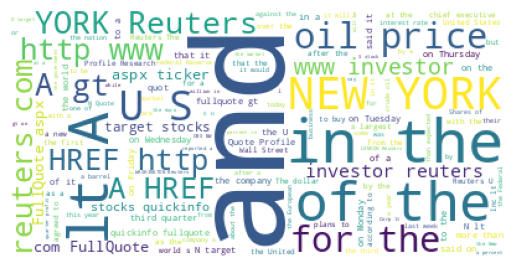

In [ ]:
word_cloud_plot(news[3])

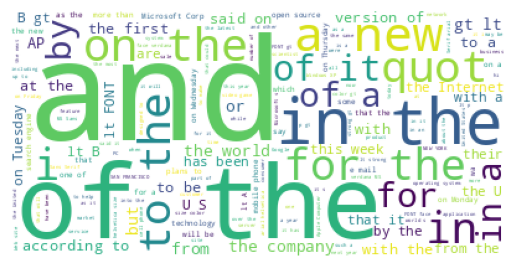

In [ ]:
word_cloud_plot(news[4])

### Визуализация топа без стоп-слов

In [ ]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [ ]:
from nltk.corpus import stopwords
stop_words = stopwords.words('english')

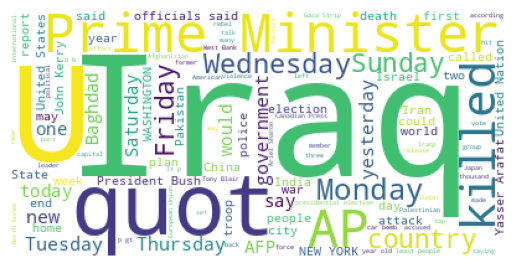

In [ ]:
word_cloud_plot(news[1], stopwords=stop_words)

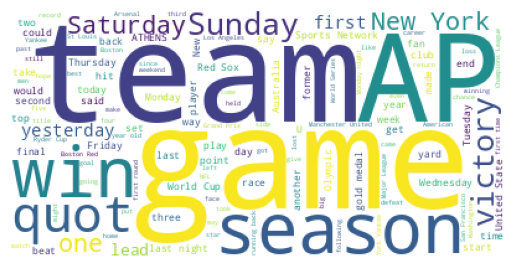

In [ ]:
word_cloud_plot(news[2], stopwords=stop_words)

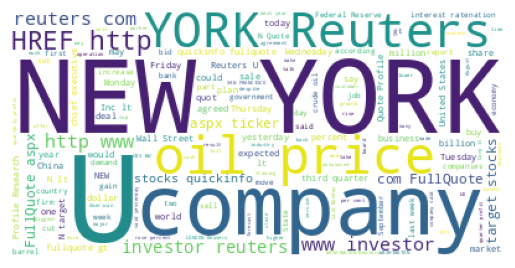

In [ ]:
word_cloud_plot(news[3], stopwords=stop_words)

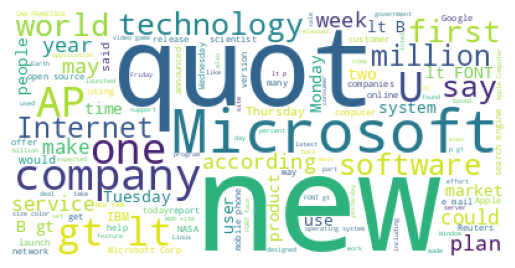

In [ ]:
word_cloud_plot(news[4], stopwords=stop_words)